# How Large Language Models Work


[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/addarm/how-llms-work)


![Banner](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/llms_how_they_work_banner.png)


## Introduction

Large language models have become an integral part of our professional lives — as copilots, search assistants, coding agents, and conversational interfaces. Most people meet them first as products. This notebook works in the opposite direction. It starts from the smallest faithful description of an LLM — a model of conditional next-token distributions — and reconstructs the full inference pipeline from first principles.

We will dip our toes into the machinery by loading a real 135 M-parameter model ([SmolLM2-135M](https://huggingface.co/HuggingFaceTB/SmolLM2-135M)), inspecting its internals, and following the path from raw text to token IDs, from token IDs to hidden states, from hidden states to logits, and from logits back to generated text. Along the way the emphasis is on *interpretation*: not just what each component does, but why it exists, what trade-off it resolves, and what breaks when it fails.

The ground we cover includes tokenisation, learned embeddings, rotary positional encoding (RoPE), scaled dot-product attention, multi-head and grouped-query attention, the full transformer block (RMSNorm, SwiGLU, residual streams), sampling strategies, KV-caching, scaling laws, post-training alignment (SFT, RLHF, DPO, LoRA), and mixture-of-experts. Each idea is paired with a runnable demo you can inspect and modify — no GPU or API keys required.

This is **Part 1 of 3**. The companion notebooks — [Prompt Engineering](prompt_engineering_how_they_work.ipynb) and [How Agents Work](agents_how_they_work.ipynb) — build on the substrate laid here, moving from model mechanics through prompt-level steering to agentic tool use and orchestration. The intended reader is a technically literate postgraduate student or practitioner: comfortable with linear algebra and neural-network basics, but not assumed to have prior NLP specialisation.


# Notebook Setup


In [1]:
!pip install torch transformers numpy pandas matplotlib seaborn scikit-learn --quiet



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json, sys, math, warnings, platform
from collections import Counter
from dataclasses import dataclass, field
from typing import Optional, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers as _tf
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}  |  Transformers {_tf.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


PyTorch 2.11.0+cpu  |  Transformers 5.6.2
Device: cpu


# Part I — The LLM Substrate

*Approximate reading time: 40 minutes.*

This part builds the full inference pipeline from first principles: tokenise → embed → positional encode → N transformer blocks (attention + FFN) → logits → softmax → sample. We use **SmolLM2-135M** — a real decoder-only LLM from the Llama family — as our running example.


## The Transformer Architecture Family

> **Reading guide.** This section uses terms like *self-attention*, *cross-attention*, and *causal mask* that are defined formally in the Attention and Transformer Block sections below. If they are unfamiliar, treat this section as a high-level roadmap — the mechanical details follow immediately after.

### The Original Transformer (2017)

Vaswani et al. (2017) introduced the transformer in *Attention Is All You Need*. The original architecture has two halves:

- **Encoder**: reads the full input sequence in parallel, producing a contextualised representation for every token. Each encoder layer applies **bidirectional self-attention** (every token attends to every other token) followed by a feed-forward network.
- **Decoder**: generates the output sequence one token at a time. Each decoder layer applies **causal (masked) self-attention** (a token can only attend to earlier positions), then **cross-attention** over the encoder's output, then a feed-forward network.

The key innovation was replacing recurrence entirely with attention, enabling massive parallelism during training.

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

This equation is the same in all three families below — what changes is **which tokens are allowed to attend to which**, and **whether both halves of the architecture are used**.

### Three Families

| Family | Architecture | Attention mask | Training objective | Representative models | Primary use-cases |
|--------|-------------|---------------|-------------------|----------------------|------------------|
| **Encoder-only** | Encoder stack only | Bidirectional (full) | Masked Language Modeling (MLM) | BERT, RoBERTa, DeBERTa | Classification, NER, retrieval |
| **Encoder-decoder** | Full original transformer | Bidirectional encoder, causal decoder | Span corruption / seq2seq | T5, BART, Flan-T5 | Translation, summarization |
| **Decoder-only** | Decoder stack only (no cross-attention) | Causal (triangular mask) | Next-token prediction | GPT-2/3/4, Llama, SmolLM2 | Text generation, chat, code |

### Why Decoder-Only Won

Radford et al. (2018) dropped the encoder entirely. GPT uses only the decoder stack trained on a single objective — predict the next token. This won because of:

- **Simplicity.** One stack, one objective, one data pipeline — dramatically simplifies scaling.
- **Scaling efficiency.** All parameters go into a single deep stack, which scales better per FLOP (Hoffmann et al., 2022).
- **Universality.** Any NLP task can be reformulated as text generation.
- **KV-cache.** No cross-attention means simpler inference caching.
- **Emergent capabilities.** At scale, decoder-only models exhibit in-context learning, chain-of-thought reasoning, and instruction-following.

> **For the rest of this notebook**, we work exclusively with the decoder-only architecture — the design behind GPT, Llama, Mistral, and SmolLM2.


## Loading a Real LLM: SmolLM2-135M

We will use **SmolLM2-135M** (Allal et al., 2025) throughout Part I.
It is a 135 M-parameter causal language model from the Llama family:
RoPE positional encoding, Grouped-Query Attention (GQA), SiLU activations,
Pre-LN transformer blocks — the same design used by Llama 3, Mistral, and Qwen2.

We load both variants:
- **Base** (`SmolLM2-135M`): pretrained next-token predictor.
- **Instruct** (`SmolLM2-135M-Instruct`): SFT + DPO aligned to follow instructions.

Later sections will compare the two.


In [3]:
# Load SmolLM2-135M base and instruct variants
BASE_ID = "HuggingFaceTB/SmolLM2-135M"
INST_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(BASE_ID)
model_base = AutoModelForCausalLM.from_pretrained(
    BASE_ID,
    dtype=torch.float32,
    attn_implementation="eager",
)
model_inst = AutoModelForCausalLM.from_pretrained(
    INST_ID,
    dtype=torch.float32,
    attn_implementation="eager",
)
model_base.eval()
model_inst.eval()
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")
print(f"Base model parameters: {sum(p.numel() for p in model_base.parameters()):,}")
print(f"Instruct model parameters: {sum(p.numel() for p in model_inst.parameters()):,}")


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Tokenizer vocab size: 49,152
Base model parameters: 134,515,008
Instruct model parameters: 134,515,008


### Model Config Inspection

Every concept we teach below (RoPE, GQA, SiLU, layer count, hidden size) is visible
in the model's `config.json`.  Let's read it directly.


In [4]:
# Inspect SmolLM2-135M architecture from its config
cfg = model_base.config
rows = [
    ("Architecture class", cfg.architectures[0] if cfg.architectures else "N/A"),
    ("Hidden size (d_model)", cfg.hidden_size),
    ("Num layers", cfg.num_hidden_layers),
    ("Num attention heads", cfg.num_attention_heads),
    ("Num KV heads (GQA)", cfg.num_key_value_heads),
    (
        "GQA ratio",
        f"{cfg.num_attention_heads}:{cfg.num_key_value_heads}  ({cfg.num_attention_heads // cfg.num_key_value_heads} queries per KV head)",
    ),
    ("Intermediate (FFN) size", cfg.intermediate_size),
    ("Activation function", cfg.hidden_act),
    ("Max position embeddings", cfg.max_position_embeddings),
    ("RoPE theta", getattr(cfg, "rope_theta", "N/A")),
    ("Vocab size", cfg.vocab_size),
    ("Tie word embeddings", cfg.tie_word_embeddings),
]
df_cfg = pd.DataFrame(rows, columns=["Parameter", "Value"])
print(df_cfg.to_string(index=False))


              Parameter                        Value
     Architecture class             LlamaForCausalLM
  Hidden size (d_model)                          576
             Num layers                           30
    Num attention heads                            9
     Num KV heads (GQA)                            3
              GQA ratio 9:3  (3 queries per KV head)
Intermediate (FFN) size                         1536
    Activation function                         silu
Max position embeddings                         8192
             RoPE theta                          N/A
             Vocab size                        49152
    Tie word embeddings                         True


## Next-Token Prediction

**Why this exists.** Language modeling reduces the enormous problem of "understanding language" to a single, well-defined objective: predict the next token given all preceding tokens.

**How it works.** An autoregressive language model factors the joint probability of a sequence as:

$$
P(x_1, x_2, \dots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, \dots, x_{t-1}).
$$

The model is trained by minimizing the **cross-entropy loss** over a training corpus:

$$
\mathcal{L} = -\sum_{t=1}^{T} \log p_\theta(x_t \mid x_{<t}),
$$

where $\theta$ are the model parameters. This objective is simple, scalable, and self-supervised: the training data is its own label.

**Training mechanics: shifted targets and teacher forcing.** During training the input sequence is $x_1, \dots, x_{T-1}$ and the target is $x_2, \dots, x_T$ — a one-position shift. Crucially, at training time the model always receives the *ground-truth* previous token as input — this is called **teacher forcing**. At inference time no ground truth is available, so the model feeds its own predictions autoregressively.

**From hidden state to logits.** The transformer produces a hidden vector $h_t \in \mathbb{R}^{d}$ at each position. The **LM head** projects this to a logit vector over the vocabulary:

$$
z_t = W_{\mathrm{LM}}\, h_t \in \mathbb{R}^{|V|},
$$

where $W_{\mathrm{LM}} \in \mathbb{R}^{|V| \times d}$. In most modern models (including SmolLM2) $W_{\mathrm{LM}}$ is **tied** to the input embedding matrix $E$, so the same parameters appear at both ends of the network.

**Engineer lens.** Next-token prediction is the foundation of *everything* that follows. Instruction following, tool use, reasoning, and agent behaviour are all shaped by post-training, but the underlying mechanism is still this autoregressive loop.

**Failure mode.** The model assigns probability mass to *every* token in the vocabulary at every step. It can generate fluent, confident, and completely wrong continuations because the objective rewards surface-level plausibility, not factual accuracy. This is the root cause of *hallucination*.


## Tokens and Embeddings

**Why this exists.** A model cannot operate on raw strings. It needs a fixed-size vocabulary of discrete units (tokens) and a way to represent them in continuous space (embeddings).

**How it works.** Subword tokenization algorithms — BPE (byte-pair encoding), SentencePiece, and byte-level variants — all solve the same tradeoff:

- **Character-level**: tiny vocabulary, very long sequences, slow to process.
- **Word-level**: manageable sequences, but the vocabulary explodes and rare words are out-of-vocabulary.
- **Subword**: intermediate vocabulary (32k–100k+), handles novel words via composition.

Each token $x_t$ is mapped to a dense vector $\mathbf{e}_t \in \mathbb{R}^d$ via an embedding matrix $E \in \mathbb{R}^{|V| \times d}$.

**Engineer lens.** Tokenization determines the effective cost of every API call (tokens are the billing unit), the maximum context a model can process, and whether multilingual or code inputs are handled efficiently.

**Failure mode.** Tokenizer mismatches between training and inference cause silent degradation. Models also struggle with character-level tasks (e.g., counting letters) because they see subword units, not characters.


### Demo 1: Real Tokenization with SmolLM2


=== Real BPE Tokenization (SmolLM2) ===

Text:   The transformer architecture revolutionized natural language processin
Tokens: ['The', 'Ġtransformer', 'Ġarchitecture', 'Ġrevolutionized', 'Ġnatural', 'Ġlanguage', 'Ġprocessing', '.']
IDs:    [504, 26832, 6277, 25774, 1782, 1789, 4604, 30]
  → 8 tokens for 72 chars (9.0 chars/tok)

Text:   SmolLM2 uses byte-level BPE with a 49,152-token vocabulary.
Tokens: ['Sm', 'ol', 'LM', '2', 'Ġuses', 'Ġbyte', '-', 'level', 'ĠB', 'PE', 'Ġwith', 'Ġa', 'Ġ', '4', '9']...
IDs:    [9207, 308, 34519, 34, 2925, 23860, 29, 4638, 389, 8198, 351, 253, 216, 36, 41]...
  → 23 tokens for 59 chars (2.6 chars/tok)

Text:   def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-
Tokens: ['def', 'Ġfib', 'onacci', '(', 'n', '):', 'Ġreturn', 'Ġn', 'Ġif', 'Ġn', 'Ġ<', 'Ġ', '2', 'Ġelse', 'Ġfib']...
IDs:    [1604, 3987, 46477, 24, 94, 727, 1003, 304, 585, 304, 2067, 216, 34, 1745, 3987]...
  → 29 tokens for 72 chars (2.5 chars/tok)

Text:   Die Transformer-A

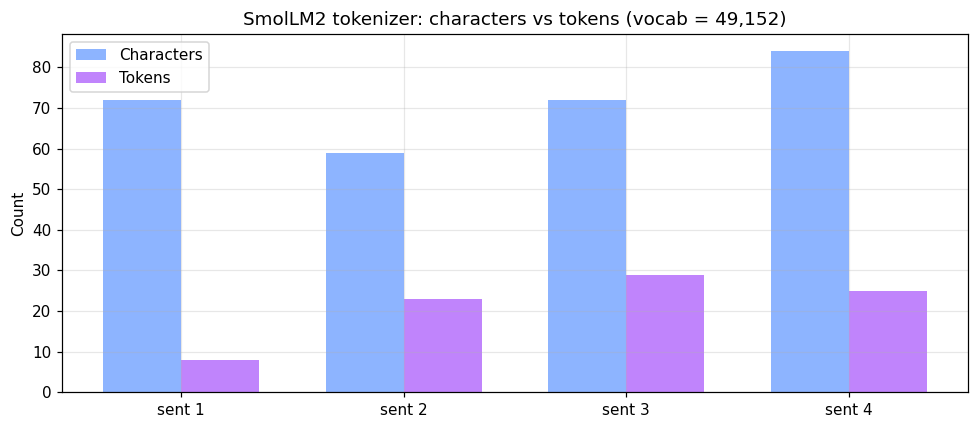

In [5]:
# Demo 1: Real BPE tokenization with SmolLM2's tokenizer
sentences = [
    "The transformer architecture revolutionized natural language processing.",
    "SmolLM2 uses byte-level BPE with a 49,152-token vocabulary.",
    "def fibonacci(n): return n if n < 2 else fibonacci(n-1) + fibonacci(n-2)",
    "Die Transformer-Architektur hat die Verarbeitung natürlicher Sprache revolutioniert.",
]

print("=== Real BPE Tokenization (SmolLM2) ===\n")
records = []
for s in sentences:
    ids = tokenizer.encode(s, add_special_tokens=False)
    toks = tokenizer.convert_ids_to_tokens(ids)
    records.append(
        {
            "text": s[:55] + ("..." if len(s) > 55 else ""),
            "chars": len(s),
            "tokens": len(ids),
            "ratio": f"{len(s) / len(ids):.1f} chars/tok",
        }
    )
    print(f"Text:   {s[:70]}")
    print(f"Tokens: {toks[:15]}{'...' if len(toks) > 15 else ''}")
    print(f"IDs:    {ids[:15]}{'...' if len(ids) > 15 else ''}")
    print(f"  → {len(ids)} tokens for {len(s)} chars ({len(s) / len(ids):.1f} chars/tok)\n")

df_tok = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(df_tok))
ax.bar(x, df_tok["chars"], width=0.35, label="Characters", color="#8db4ff", align="center")
ax.bar([i + 0.35 for i in x], df_tok["tokens"], width=0.35, label="Tokens", color="#c084fc", align="center")
ax.set_xticks([i + 0.175 for i in x])
ax.set_xticklabels([f"sent {i + 1}" for i in x])
ax.set_ylabel("Count")
ax.set_title(f"SmolLM2 tokenizer: characters vs tokens (vocab = {tokenizer.vocab_size:,})")
ax.legend()
plt.tight_layout()
plt.show()


### Demo 2: Real Embedding Similarity


Embedding matrix shape: torch.Size([49152, 576])  (vocab × d_model)


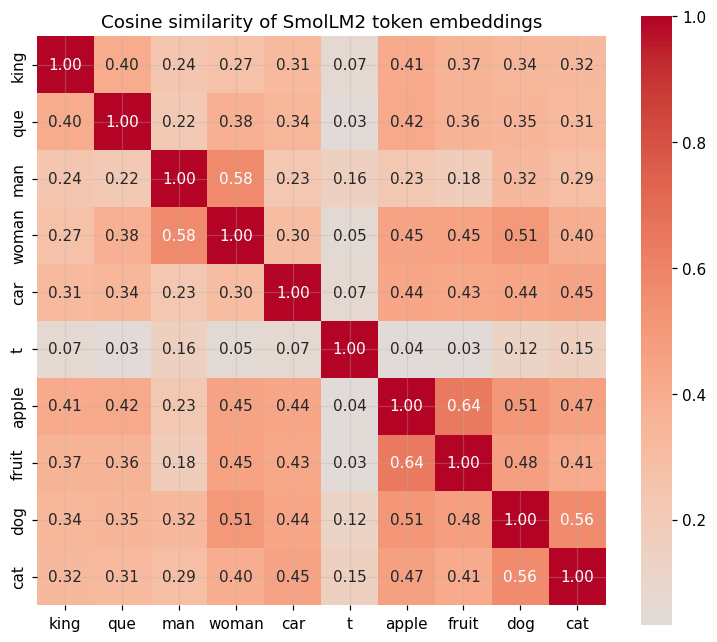

Note: pretrained embeddings already encode semantic structure — no hand-crafting needed.


In [6]:
# Demo 2: Cosine similarity from SmolLM2's learned embedding table
probe_words = ["king", "queen", "man", "woman", "car", "truck", "apple", "fruit", "dog", "cat"]

emb_matrix = model_base.get_input_embeddings().weight.detach()
print(f"Embedding matrix shape: {emb_matrix.shape}  (vocab × d_model)")

# Look up each word — take first token if subword-split
vecs = []
resolved = []
for w in probe_words:
    ids = tokenizer.encode(w, add_special_tokens=False)
    tok_str = tokenizer.convert_ids_to_tokens(ids)[0]
    vecs.append(emb_matrix[ids[0]].numpy())
    resolved.append(tok_str)

vecs = np.stack(vecs)
norms = np.linalg.norm(vecs, axis=1, keepdims=True)
normed = vecs / norms
sim = normed @ normed.T

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(sim, annot=True, fmt=".2f", xticklabels=resolved, yticklabels=resolved, cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Cosine similarity of SmolLM2 token embeddings")
plt.tight_layout()
plt.show()
print("Note: pretrained embeddings already encode semantic structure — no hand-crafting needed.")


## Positional Encoding

**Why this exists.** Self-attention treats its input as a *set* — it has no notion of token order. Without positional information, "the cat sat on the mat" and "mat the on sat cat the" are identical.

**How it works.** The original transformer (Vaswani et al., 2017) adds sinusoidal positional encodings to the token embeddings:

$$
PE_{(pos, 2i)} = \sin\!\Big(\frac{pos}{10000^{2i/d}}\Big), \qquad
PE_{(pos, 2i+1)} = \cos\!\Big(\frac{pos}{10000^{2i/d}}\Big).
$$

Modern models (Llama, Mistral, SmolLM2) use **Rotary Position Embeddings (RoPE)** (Su et al., 2021). Instead of adding a positional vector, RoPE applies a *rotation* to each query and key vector before the attention dot product. The key property:

$$
\langle \mathbf{R}(m)\,q,\; \mathbf{R}(n)\,k \rangle = q^\top \mathbf{R}(n - m)\, k,
$$

so the inner product depends **only on the relative offset** $n - m$, not on absolute positions.

SmolLM2 uses RoPE with $\theta = 100{,}000$. Extending context beyond training length is handled via **YaRN** or **NTK-aware interpolation**.

**Engineer lens.** Positional encoding determines the maximum effective context length. Extending context beyond training length requires interpolation techniques.

**Failure mode.** Models can degrade unpredictably on sequences longer than their trained context, even with interpolation.


### Demo 3: Positional Encoding Heatmap


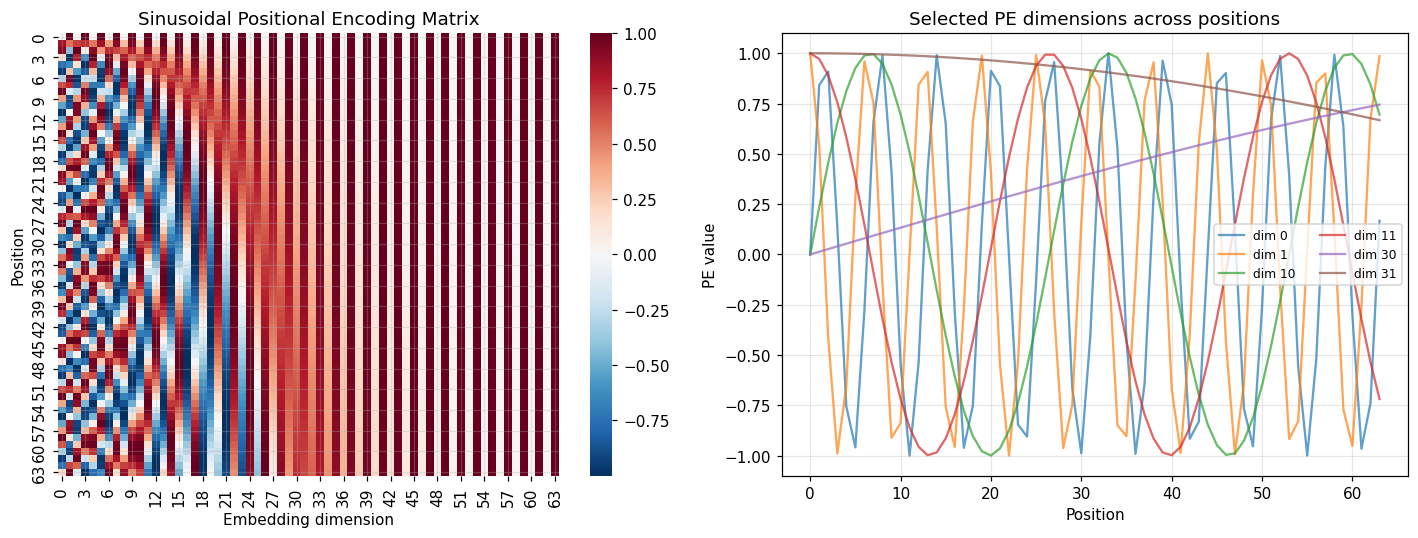

In [7]:
# Demo 3: Sinusoidal positional encoding visualization
seq_len, d_model = 64, 64
pe = np.zeros((seq_len, d_model))
position = np.arange(seq_len)[:, None]
div_term = 10000.0 ** (np.arange(0, d_model, 2) / d_model)
pe[:, 0::2] = np.sin(position / div_term)
pe[:, 1::2] = np.cos(position / div_term)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(pe, cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_xlabel("Embedding dimension")
axes[0].set_ylabel("Position")
axes[0].set_title("Sinusoidal Positional Encoding Matrix")

for dim_idx in [0, 1, 10, 11, 30, 31]:
    axes[1].plot(pe[:, dim_idx], label=f"dim {dim_idx}", alpha=0.7)
axes[1].set_xlabel("Position")
axes[1].set_ylabel("PE value")
axes[1].set_title("Selected PE dimensions across positions")
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## Scaled Dot-Product Attention

**Why this exists.** Earlier sequence models (RNNs, LSTMs) process tokens one at a time, creating a sequential bottleneck. Attention lets every token interact with every other token in *parallel*.

**How it works.** Each token's representation $X \in \mathbb{R}^{B \times T \times d}$ is linearly projected to three role-specific matrices:

$$
Q = X W^Q, \quad K = X W^K, \quad V = X W^V.
$$

The attention output is:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V.
$$

**Why divide by $\sqrt{d_k}$?** When the components of $q$ and $k$ are independent with zero mean and unit variance, the dot product $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ has variance $d_k$. Dividing by $\sqrt{d_k}$ restores unit variance, keeping the softmax in a regime where gradients flow.

For **causal (autoregressive) models**, a mask sets all future positions $j > i$ to $-\infty$ before softmax, ensuring that token $i$ can only attend to tokens $\leq i$.

> **Common confusion.** Attention weights show *which positions contributed to the output*, but they are not explanations of *why*. Attention is a soft routing mechanism, not a causal explanation.

**Engineer lens.** Attention has $O(T^2 \cdot d)$ time and $O(T^2)$ memory cost. FlashAttention (Dao et al., 2022) fuses the operations to avoid materialising the $T \times T$ matrix, reducing memory to $O(T)$.

**Failure mode.** In very long contexts, attention spreads thinly and models struggle to retrieve information from the middle (*lost in the middle*, Liu et al. 2023).


### Demo 4: Self-Attention Heatmap


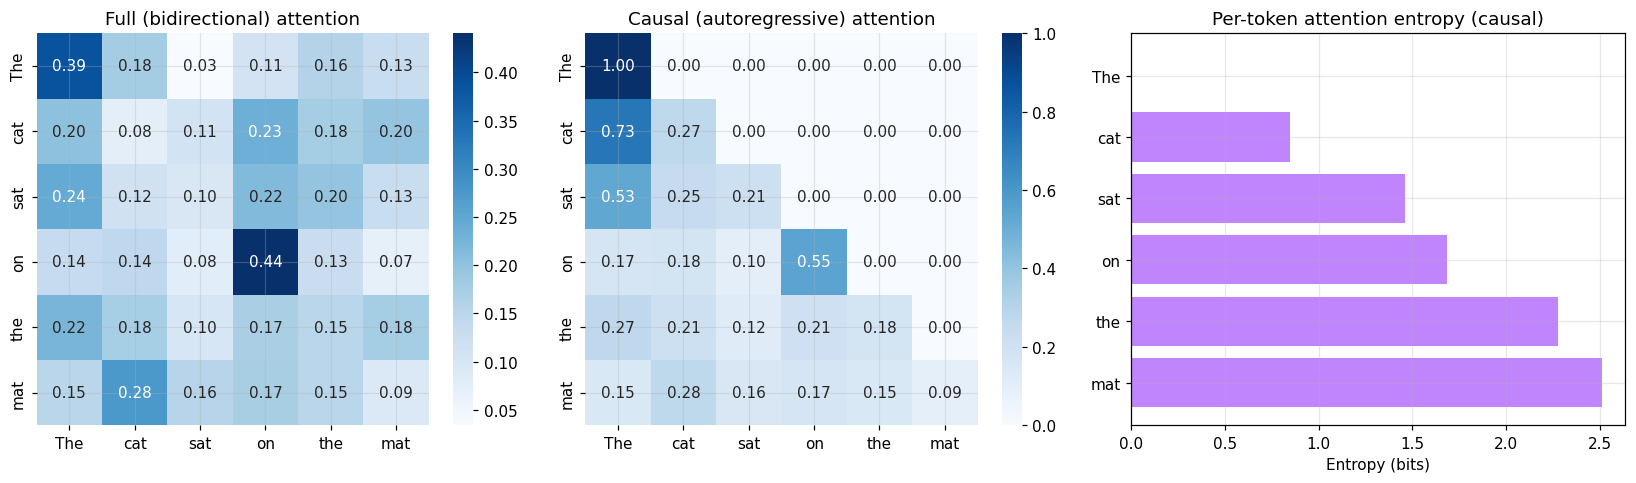

Max entropy for T=6 positions: 2.58 bits (uniform attention)


In [8]:
# Demo 4: Scaled dot-product attention — unmasked vs causally masked
tokens = ["The", "cat", "sat", "on", "the", "mat"]
T, d_k = len(tokens), 8

Q = rng.standard_normal((T, d_k))
K = rng.standard_normal((T, d_k))
V = rng.standard_normal((T, d_k))

# Raw scores
scores = Q @ K.T / np.sqrt(d_k)


# Softmax
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


attn_full = softmax(scores)

# Causal mask
causal_mask = np.triu(np.ones((T, T), dtype=bool), k=1)
scores_masked = scores.copy()
scores_masked[causal_mask] = -1e9
attn_causal = softmax(scores_masked)


# Attention entropy (bits)
def entropy(p, axis=-1):
    p_safe = np.clip(p, 1e-12, 1.0)
    return -(p_safe * np.log2(p_safe)).sum(axis=axis)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.heatmap(attn_full, annot=True, fmt=".2f", xticklabels=tokens, yticklabels=tokens, cmap="Blues", ax=axes[0], square=True)
axes[0].set_title("Full (bidirectional) attention")

sns.heatmap(attn_causal, annot=True, fmt=".2f", xticklabels=tokens, yticklabels=tokens, cmap="Blues", ax=axes[1], square=True)
axes[1].set_title("Causal (autoregressive) attention")

ent = entropy(attn_causal)
axes[2].barh(tokens, ent, color="#c084fc")
axes[2].set_xlabel("Entropy (bits)")
axes[2].set_title("Per-token attention entropy (causal)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()
print(f"Max entropy for T={T} positions: {np.log2(T):.2f} bits (uniform attention)")


## Multi-Head Attention

**Why this exists.** A single attention head can only learn one attention pattern per layer. Multiple heads let the model attend to different types of relationships simultaneously.

**How it works.**

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) \, W^O,
$$

where each head computes attention independently with its own projections:

$$
\text{head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V).
$$

**Grouped-Query Attention (GQA)** (Ainslie et al., 2023). Full MHA requires caching $h$ K and $h$ V tensors per layer. GQA reduces this by sharing: $h_K = h_V < h_Q$, with $G = h_Q / h_K$ query heads per KV head.

SmolLM2-135M uses $h_Q = 9$, $h_K = h_V = 3$, so $G = 3$. The KV-cache per token is:

$$
\text{KV bytes per token} = 2 \times L \times h_K \times d_k \times \text{bytes},
$$

3× smaller than full MHA at the same $d_{\text{model}}$.

**Engineer lens.** GQA is now the default in every leading open-weight model: Llama 3, Qwen 2.5, Mistral, Gemma 2, and SmolLM2.

**Failure mode.** Heads can become redundant (attention collapse), especially in deeper layers.


### Demo 5: GQA Head Grouping Visualised

SmolLM2 has **9 query heads** grouped into **3 KV groups** (3 query heads per KV head).
Within a group, all query heads share the same K and V projections but have independent Q
projections, so they can still learn different attention patterns.

This cell runs a forward pass with `output_attentions=True`, visualises all 9 heads
from the last layer arranged by KV group, then measures how similar the attention patterns
are within vs. across groups.


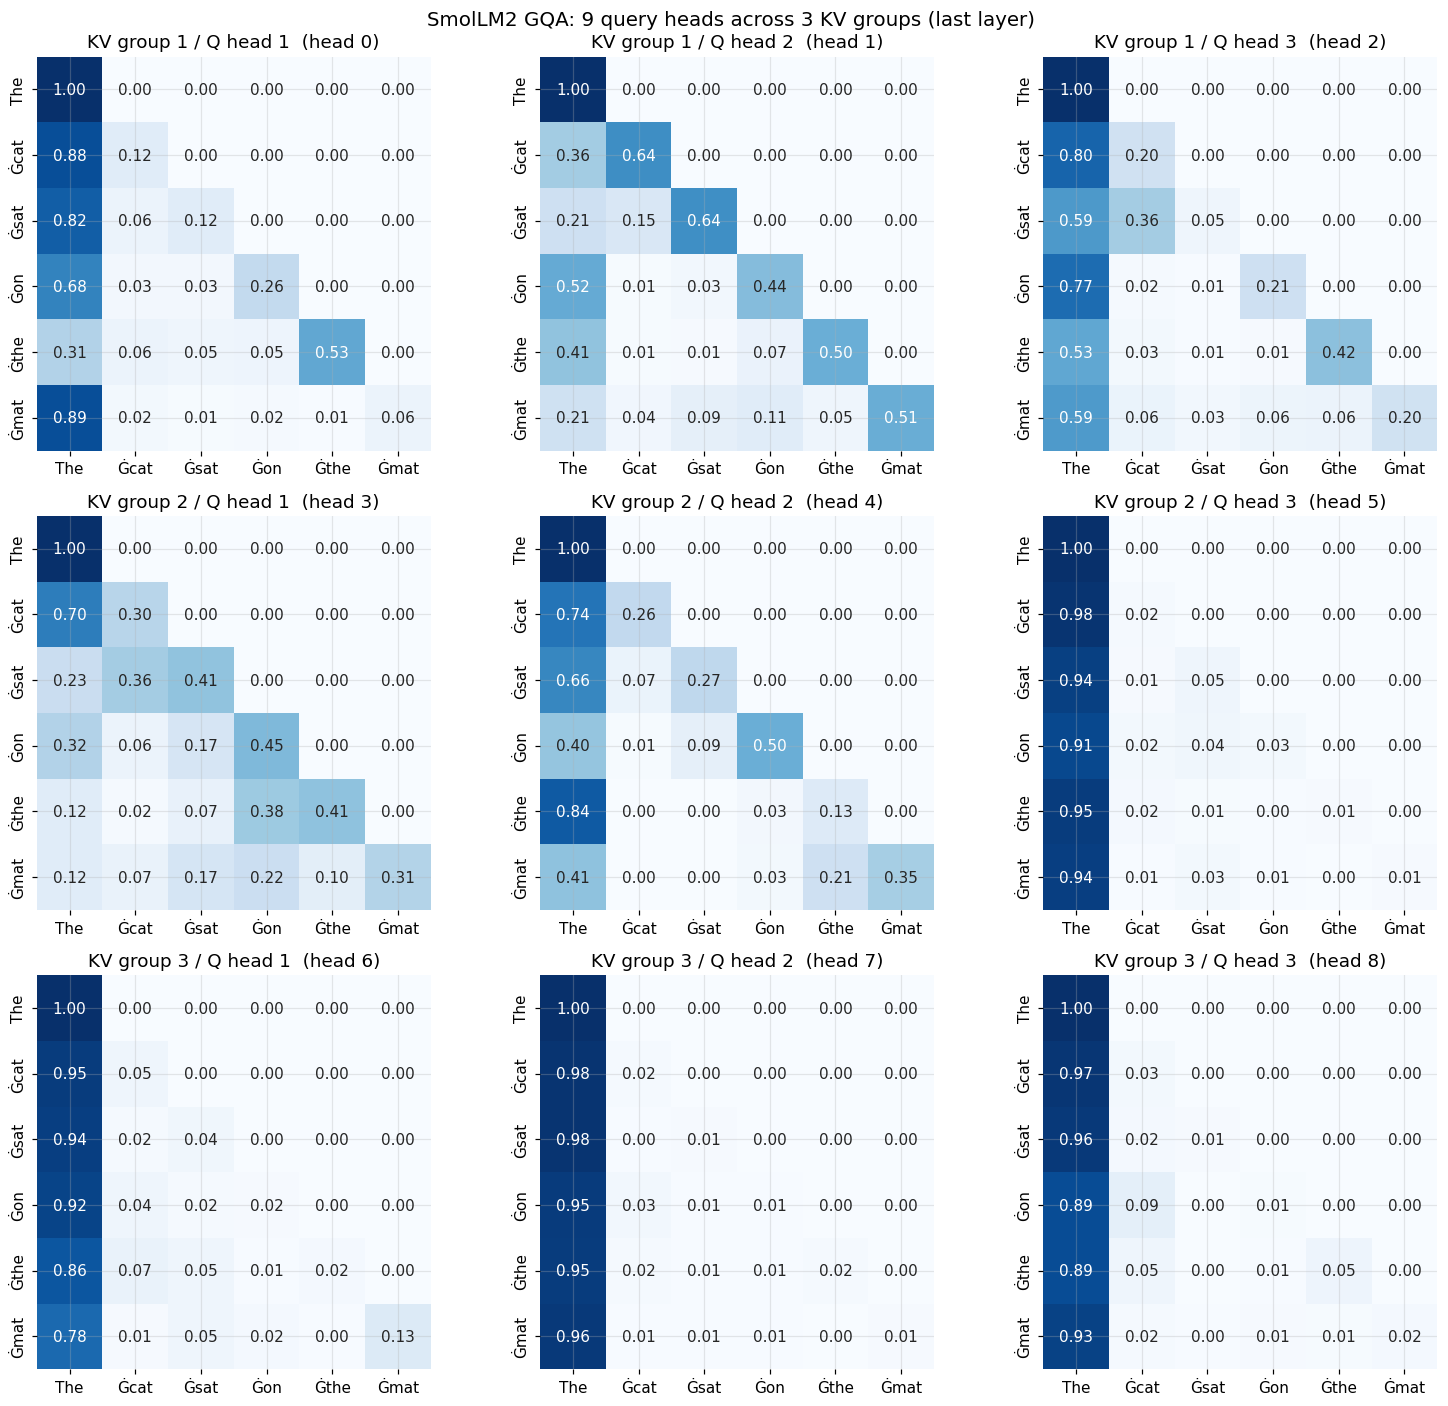

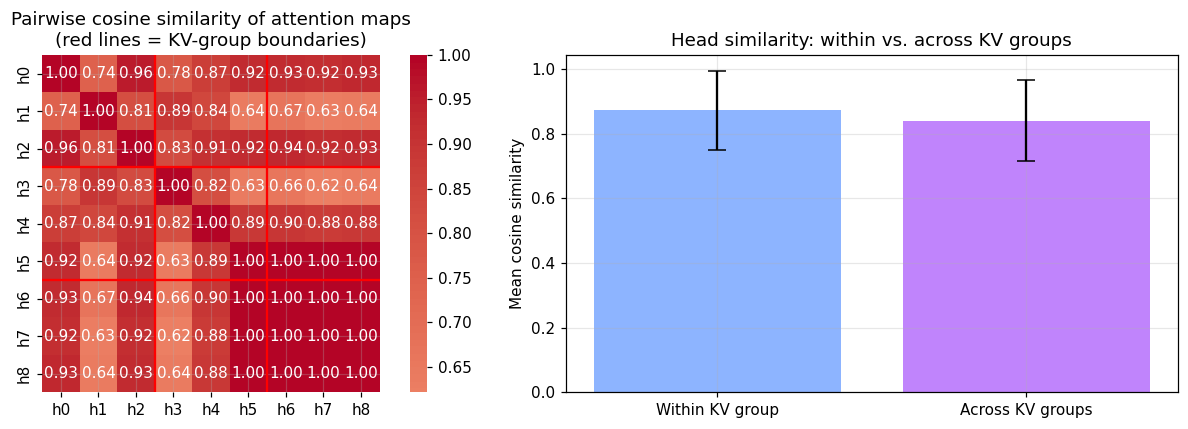

Within-group similarity  (mean ± std): 0.871 ± 0.122
Across-group similarity  (mean ± std): 0.840 ± 0.126
Within-group heads share K/V but have independent Q → can still learn different patterns.


In [9]:
# Demo 5: GQA head grouping — all 9 query heads from the last layer
probe5b_text = "The cat sat on the mat"
probe5b_ids = tokenizer.encode(probe5b_text, return_tensors="pt")
probe5b_toks = tokenizer.convert_ids_to_tokens(probe5b_ids[0].tolist())

with torch.no_grad():
    out5b = model_base(probe5b_ids, output_attentions=True)

attn_all = out5b.attentions[-1][0].float().numpy()  # (9, T, T)
n_q_heads = attn_all.shape[0]  # 9
G = model_base.config.num_attention_heads // model_base.config.num_key_value_heads  # 3
n_kv = n_q_heads // G  # 3 KV groups

fig, axes = plt.subplots(n_kv, G, figsize=(14, 13))
for kv_group in range(n_kv):
    for q_offset in range(G):
        h = kv_group * G + q_offset
        ax = axes[kv_group][q_offset]
        sns.heatmap(
            attn_all[h],
            annot=True,
            fmt=".2f",
            xticklabels=probe5b_toks,
            yticklabels=probe5b_toks,
            cmap="Blues",
            ax=ax,
            square=True,
            cbar=False,
        )
        ax.set_title(f"KV group {kv_group + 1} / Q head {q_offset + 1}  (head {h})")

fig.suptitle("SmolLM2 GQA: 9 query heads across 3 KV groups (last layer)", fontsize=13)
plt.tight_layout()
plt.show()

# Pairwise cosine similarity of attention maps
flat = attn_all.reshape(n_q_heads, -1)
norms5b = np.linalg.norm(flat, axis=1, keepdims=True)
flat_n = flat / (norms5b + 1e-9)
sim5b = flat_n @ flat_n.T  # (9, 9)

within_sims, across_sims = [], []
for i in range(n_q_heads):
    for j in range(i + 1, n_q_heads):
        s = sim5b[i, j]
        if (i // G) == (j // G):
            within_sims.append(s)
        else:
            across_sims.append(s)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(
    sim5b,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes2[0],
    square=True,
    xticklabels=[f"h{i}" for i in range(n_q_heads)],
    yticklabels=[f"h{i}" for i in range(n_q_heads)],
)
for g in range(1, n_kv):
    axes2[0].axhline(g * G, color="red", lw=1.5)
    axes2[0].axvline(g * G, color="red", lw=1.5)
axes2[0].set_title("Pairwise cosine similarity of attention maps\n(red lines = KV-group boundaries)")

axes2[1].bar(
    ["Within KV group", "Across KV groups"],
    [np.mean(within_sims), np.mean(across_sims)],
    yerr=[np.std(within_sims), np.std(across_sims)],
    color=["#8db4ff", "#c084fc"],
    capsize=6,
)
axes2[1].set_ylabel("Mean cosine similarity")
axes2[1].set_title("Head similarity: within vs. across KV groups")
plt.tight_layout()
plt.show()

print(f"Within-group similarity  (mean ± std): {np.mean(within_sims):.3f} ± {np.std(within_sims):.3f}")
print(f"Across-group similarity  (mean ± std): {np.mean(across_sims):.3f} ± {np.std(across_sims):.3f}")
print("Within-group heads share K/V but have independent Q → can still learn different patterns.")


## The Transformer Block

**Why this exists.** Attention alone is a weighted average — it needs nonlinearity, normalization, and residual connections to become a powerful function approximator. The **transformer block** wraps attention into a repeatable unit.

**How it works.** Each block performs (in the Pre-LN variant used by most modern LLMs):

$$
\tilde{x} = x + \text{Attn}(\text{Norm}(x)), \qquad
x' = \tilde{x} + \text{FFN}(\text{Norm}(\tilde{x})).
$$

**RMSNorm.** Most LLMs since Llama replace LayerNorm with **RMSNorm** (Zhang & Sennrich, 2019):

$$
\text{RMSNorm}(x) = \frac{x}{\text{RMS}(x)} \cdot \gamma, \qquad \text{RMS}(x) = \sqrt{\tfrac{1}{d}\sum_i x_i^2 + \epsilon}.
$$

**SwiGLU FFN.** SmolLM2 uses the SwiGLU variant (Shazeer, 2020):

$$
\text{FFN}_{\text{SwiGLU}}(x) = \bigl(W_1 x \odot \text{SiLU}(W_3 x)\bigr) W_2,
$$

where $\text{SiLU}(z) = z \cdot \sigma(z)$. SmolLM2: $d=576$, $d_{ff}=1536$.

A model with $N$ blocks stacks this unit $N$ times. SmolLM2-135M uses 30.

**Prefill vs decode.** During *prefill*, all $T$ input tokens are processed in parallel — compute is $O(T^2 d)$. During *decode*, only the new token runs through each block while past keys and values are read from the **KV-cache** — compute is $O(T d)$ per step.

The **KV-cache memory** at sequence length $T$, batch size $B$, in BF16:

$$
\text{KV bytes} = 2 \times L \times h_K \times d_k \times T \times B \times 2.
$$

**Engineer lens.** The KV-cache trades memory for compute. For Llama 3 70B at $T=8192$, $B=8$: $\approx 120\,\text{GB}$ — larger than model weights for some GPU configurations.

**Failure mode.** Residual stream saturation: in very deep models, the residual stream can accumulate drift, and later layers may struggle to override earlier representations.


### Demo 6: Real Transformer Forward Pass


=== SmolLM2-135M Forward Pass ===

Input:  'The transformer architecture'
Tokens: ['The', 'Ġtransformer', 'Ġarchitecture']
IDs:    [504, 26832, 6277]

Layer      Hidden shape          Norm (mean)
--------------------------------------------
embed      (1, 3, 576)                2.3912
layer 1    (1, 3, 576)               57.1708
layer 2    (1, 3, 576)               96.8783
layer 3    (1, 3, 576)              278.9663
layer 4    (1, 3, 576)              283.0894
layer 5    (1, 3, 576)              284.3609
layer 6    (1, 3, 576)              287.0778
layer 7    (1, 3, 576)              289.8520
layer 8    (1, 3, 576)              297.0836
layer 9    (1, 3, 576)              281.2467
layer 10   (1, 3, 576)              156.4077
layer 11   (1, 3, 576)              142.3080
layer 12   (1, 3, 576)             6573.8081
layer 13   (1, 3, 576)             6570.4282
layer 14   (1, 3, 576)             6571.5293
layer 15   (1, 3, 576)             6577.5117
layer 16   (1, 3, 576)             6576

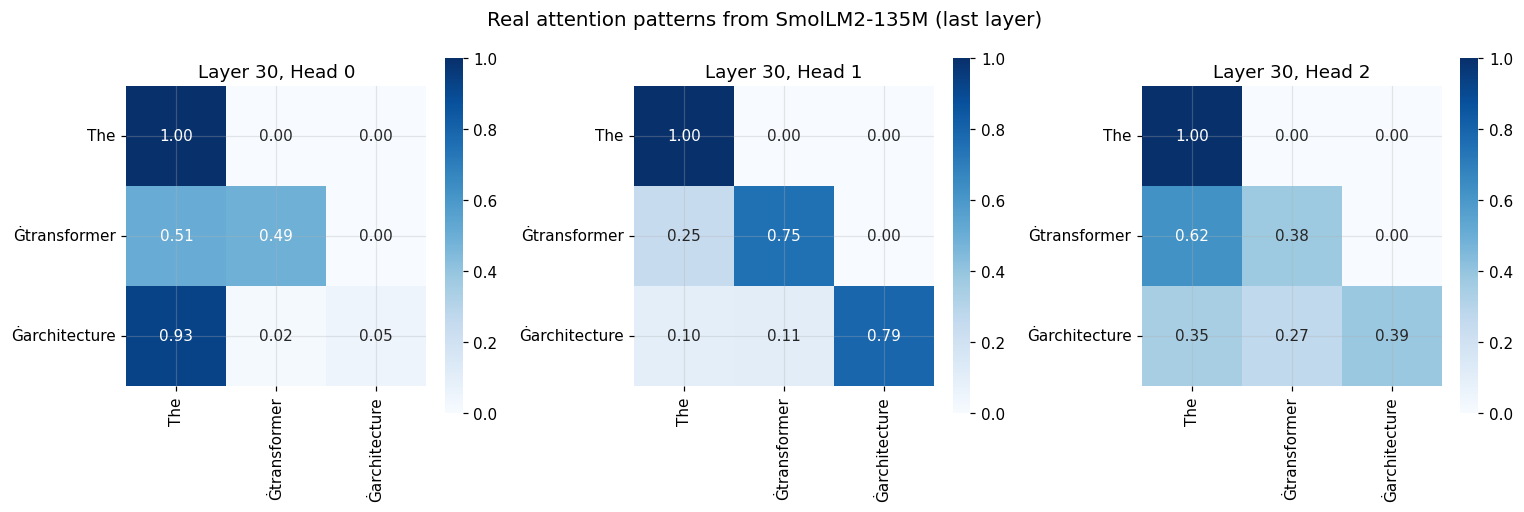

In [10]:
# Demo 6: Trace a real forward pass through SmolLM2-135M
prompt_text = "The transformer architecture"
input_ids = tokenizer.encode(prompt_text, return_tensors="pt")
tokens_str = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

print(f"=== SmolLM2-135M Forward Pass ===\n")
print(f"Input:  '{prompt_text}'")
print(f"Tokens: {tokens_str}")
print(f"IDs:    {input_ids[0].tolist()}\n")

with torch.no_grad():
    outputs = model_base(input_ids, output_hidden_states=True, output_attentions=True)

logits = outputs.logits
hidden_states = outputs.hidden_states  # tuple: embedding + 30 layers
attentions = outputs.attentions  # tuple: 30 layers

print(f"{'Layer':<10} {'Hidden shape':<20} {'Norm (mean)':>12}")
print("-" * 44)
for i, hs in enumerate(hidden_states):
    label = "embed" if i == 0 else f"layer {i}"
    norm = hs.float().norm(dim=-1).mean().item()
    print(f"{label:<10} {str(tuple(hs.shape)):<20} {norm:>12.4f}")

print(f"\nLogits shape: {tuple(logits.shape)}  (batch, seq_len, vocab)")
top5 = torch.topk(logits[0, -1], 5)
print(f"\nTop-5 next-token predictions after '{prompt_text}':")
for tok_id, logit_val in zip(top5.indices, top5.values):
    tok_str = tokenizer.decode(tok_id.item())
    print(f"  {tok_str!r:>15s}  logit={logit_val.item():.2f}")

# Plot attention from last layer, head 0
attn_last = attentions[-1][0]  # (n_heads, T, T)
fig, axes = plt.subplots(1, min(3, attn_last.shape[0]), figsize=(14, 4.5))
if not hasattr(axes, "__len__"):
    axes = [axes]
for h, ax in enumerate(axes):
    sns.heatmap(
        attn_last[h].float().numpy(),
        annot=True,
        fmt=".2f",
        xticklabels=tokens_str,
        yticklabels=tokens_str,
        cmap="Blues",
        ax=ax,
        square=True,
    )
    ax.set_title(f"Layer {len(attentions)}, Head {h}")
fig.suptitle("Real attention patterns from SmolLM2-135M (last layer)", fontsize=13)
plt.tight_layout()
plt.show()


### Demo 7: Logits → Next Token → Loss

This cell makes the full prediction pipeline concrete: last hidden state $h_t$ → LM head
projection → logits $z_t$ → softmax → probabilities → cross-entropy loss $\ell_t$ →
perplexity.


Last hidden state  h_T:  shape=(576,), norm=48.298
Logit vector       z_T:  shape=(49152,), range=[-3.74, 28.59]
Tied embeddings?   True

Top-5 predicted next tokens:
  Token                 Probability    Log-prob
  ----------------------------------------------
  ' is'                    0.238523     -1.4333
  ' of'                    0.131452     -2.0291
  ' has'                   0.049689     -3.0020
  ' can'                   0.030881     -3.4776
  ' was'                   0.030620     -3.4861

Cross-entropy loss for target ' is'          : ℓ = 1.4333 nats  →  perplexity = 4.1925
Cross-entropy loss for target 'ри'           : ℓ = 18.2917 nats  →  perplexity = 87900960.0000

Base-line loss (uniform over 49,152-token vocab): 10.80 nats


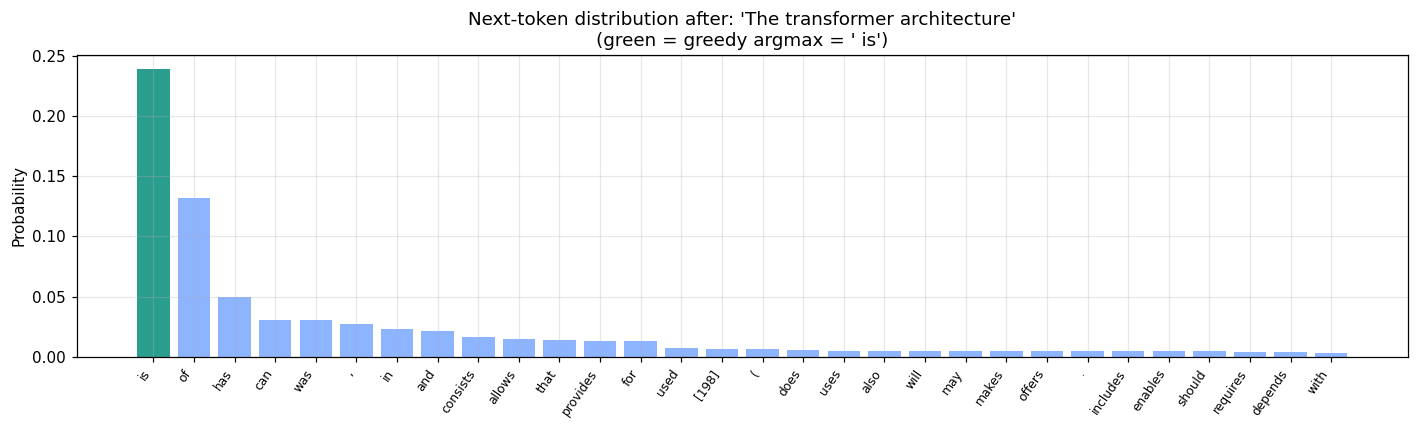

In [11]:
# Demo 7: Full logits → probability → loss pipeline on a real SmolLM2 forward pass

# 1. Pick the last token position (position T-1)
last_hidden = hidden_states[-1][0, -1]  # (d_model,) = (576,)
print(f"Last hidden state  h_T:  shape={tuple(last_hidden.shape)}, norm={last_hidden.float().norm().item():.3f}")

# 2. Project through LM head  (W_LM h_T → z_T)
with torch.no_grad():
    logits_last = model_base.lm_head(last_hidden.unsqueeze(0)).squeeze(0).float()

print(f"Logit vector       z_T:  shape={tuple(logits_last.shape)}, range=[{logits_last.min():.2f}, {logits_last.max():.2f}]")
print(f"Tied embeddings?   {model_base.config.tie_word_embeddings}")
print()

# 3. Softmax → probabilities
probs_last = torch.softmax(logits_last, dim=-1).numpy()
top5_idx = np.argsort(-probs_last)[:5]
print("Top-5 predicted next tokens:")
print(f"  {'Token':<20} {'Probability':>12}  {'Log-prob':>10}")
print("  " + "-" * 46)
for idx in top5_idx:
    tok = tokenizer.decode(int(idx))
    prob = probs_last[idx]
    lp = np.log(prob + 1e-45)
    print(f"  {repr(tok):<20} {prob:>12.6f}  {lp:>10.4f}")

# 4. Cross-entropy loss for a chosen target token
target_id_greedy = int(top5_idx[0])
target_tok_greedy = tokenizer.decode(target_id_greedy)
loss_greedy = -np.log(probs_last[target_id_greedy] + 1e-45)
ppl_greedy = np.exp(loss_greedy)
print(f"\nCross-entropy loss for target {repr(target_tok_greedy):<15}: ℓ = {loss_greedy:.4f} nats  →  perplexity = {ppl_greedy:.4f}")

rng_token_id = int(rng.integers(0, tokenizer.vocab_size))
rng_tok_str = tokenizer.decode(rng_token_id)
loss_rng = -np.log(probs_last[rng_token_id] + 1e-45)
ppl_rng = np.exp(loss_rng)
print(f"Cross-entropy loss for target {repr(rng_tok_str):<15}: ℓ = {loss_rng:.4f} nats  →  perplexity = {ppl_rng:.4f}")

print(f"\nBase-line loss (uniform over {tokenizer.vocab_size:,}-token vocab): {np.log(tokenizer.vocab_size):.2f} nats")

# 5. Plot: probability mass (top 30 tokens)
top30_idx = np.argsort(-probs_last)[:30]
top30_probs = probs_last[top30_idx]
top30_labels = [tokenizer.decode(int(i)).strip() or f"[{i}]" for i in top30_idx]

fig, ax = plt.subplots(figsize=(13, 4))
colors7 = ["#2a9d8f" if i == 0 else "#8db4ff" for i in range(30)]
ax.bar(range(30), top30_probs, color=colors7)
ax.set_xticks(range(30))
ax.set_xticklabels(top30_labels, rotation=55, ha="right", fontsize=8)
ax.set_ylabel("Probability")
prompt_display = tokenizer.decode(input_ids[0].tolist())
ax.set_title(f"Next-token distribution after: '{prompt_display}'\n(green = greedy argmax = {repr(target_tok_greedy)})")
plt.tight_layout()
plt.show()


## From Logits to Text: Softmax and Sampling

**Why this exists.** The transformer outputs a logit vector $z \in \mathbb{R}^{|V|}$ at each position. We need to convert this to a probability distribution and *sample* a token.

**Temperature scaling** sharpens or flattens the distribution before softmax:

$$
p_i = \frac{e^{z_i / \tau}}{\sum_j e^{z_j / \tau}},
$$

where $\tau < 1$ sharpens (more deterministic) and $\tau > 1$ flattens (more random).

**Top-p (nucleus) sampling** (Holtzman et al., 2020) restricts sampling to the smallest set of tokens whose cumulative probability exceeds a threshold $p$:

$$
\mathcal{V}_p = \underset{S \subseteq V}{\arg\min} \; |S| \quad \text{s.t.} \quad \sum_{i \in S} p_i \geq p.
$$

**Engineer lens.** Sampling is a critical tuning knob. Greedy decoding ($\tau \to 0$) gives deterministic but often repetitive output. Temperature + top-p together control diversity vs coherence.

**Failure mode.** Too-high temperature produces incoherent text. Too-low temperature produces repetitive loops.


### Demo 8: Temperature and Top-p on Real Logits


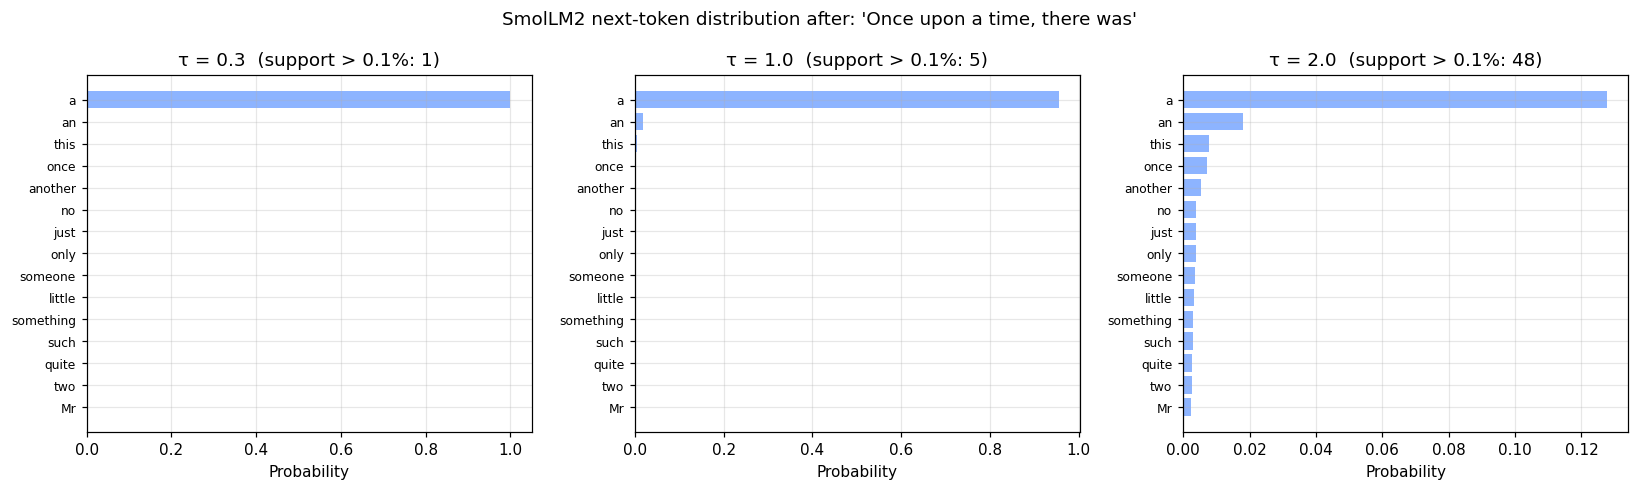

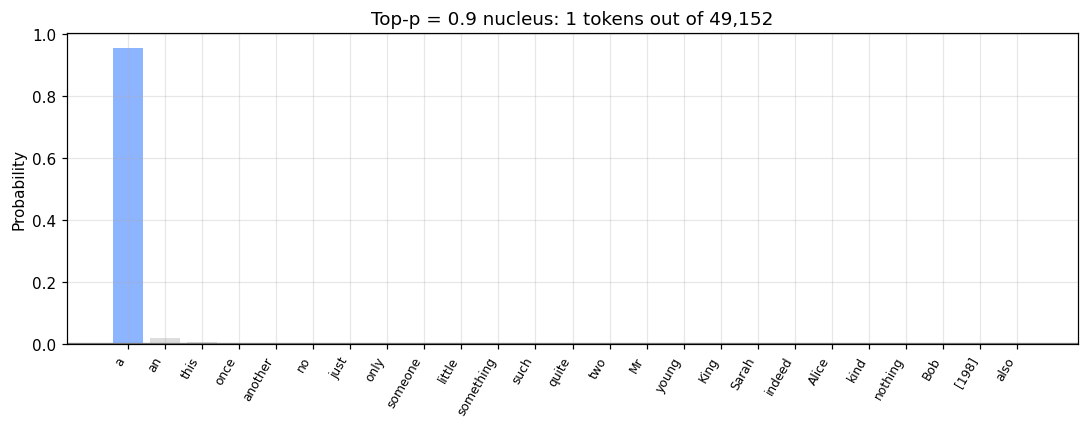

In [12]:
# Demo 8: Temperature and top-p on real SmolLM2 logits
prompt_samp = "Once upon a time, there was"
ids_samp = tokenizer.encode(prompt_samp, return_tensors="pt")

with torch.no_grad():
    logits_samp = model_base(ids_samp).logits[0, -1].float()


# Numpy softmax helper
def np_softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()


logits_np = logits_samp.numpy()

temperatures = [0.3, 1.0, 2.0]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, tau in zip(axes, temperatures):
    probs = np_softmax(logits_np / tau)
    top_k_idx = np.argsort(-probs)[:15]
    top_probs = probs[top_k_idx]
    top_tokens = [tokenizer.decode(int(i)).strip() or f"[{i}]" for i in top_k_idx]
    ax.barh(range(len(top_tokens)), top_probs, color="#8db4ff")
    ax.set_yticks(range(len(top_tokens)))
    ax.set_yticklabels(top_tokens, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Probability")
    eff_support = int((probs > 0.001).sum())
    ax.set_title(f"τ = {tau}  (support > 0.1%: {eff_support})")

fig.suptitle(f"SmolLM2 next-token distribution after: '{prompt_samp}'", fontsize=12)
plt.tight_layout()
plt.show()

# Top-p cutoff at tau=1
probs_base_samp = np_softmax(logits_np)
sorted_idx = np.argsort(-probs_base_samp)
sorted_probs = probs_base_samp[sorted_idx]
cumulative = np.cumsum(sorted_probs)
top_n = int((cumulative <= 0.9).sum()) + 1

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#8db4ff" if i < top_n else "#ddd" for i in range(min(25, len(sorted_probs)))]
tok_labels = [tokenizer.decode(int(sorted_idx[i])).strip() or f"[{sorted_idx[i]}]" for i in range(min(25, len(sorted_probs)))]
ax.bar(range(min(25, len(sorted_probs))), sorted_probs[:25], color=colors)
ax.set_xticks(range(min(25, len(sorted_probs))))
ax.set_xticklabels(tok_labels, rotation=60, ha="right", fontsize=8)
ax.axhline(0, color="gray")
ax.set_ylabel("Probability")
ax.set_title(f"Top-p = 0.9 nucleus: {top_n} tokens out of {tokenizer.vocab_size:,}")
plt.tight_layout()
plt.show()


### Demo 9: Autoregressive Text Generation


=== Autoregressive Generation (SmolLM2-135M base) ===

Prompt: 'The key idea behind the transformer architecture is'

Step   New token       Cumulative text
----------------------------------------------------------------------
0      ' that'         The key idea behind the transformer architecture is that
1      ' it'           The key idea behind the transformer architecture is that it
2      '’'             The key idea behind the transformer architecture is that it’
3      's'             The key idea behind the transformer architecture is that it’s
4      ' fundamentally' The key idea behind the transformer architecture is that it’s fundamen
5      ' a'            The key idea behind the transformer architecture is that it’s fundamen
6      ' mechanical'   The key idea behind the transformer architecture is that it’s fundamen
7      ' device'       The key idea behind the transformer architecture is that it’s fundamen
8      ' with'         The key idea behind the transformer arch

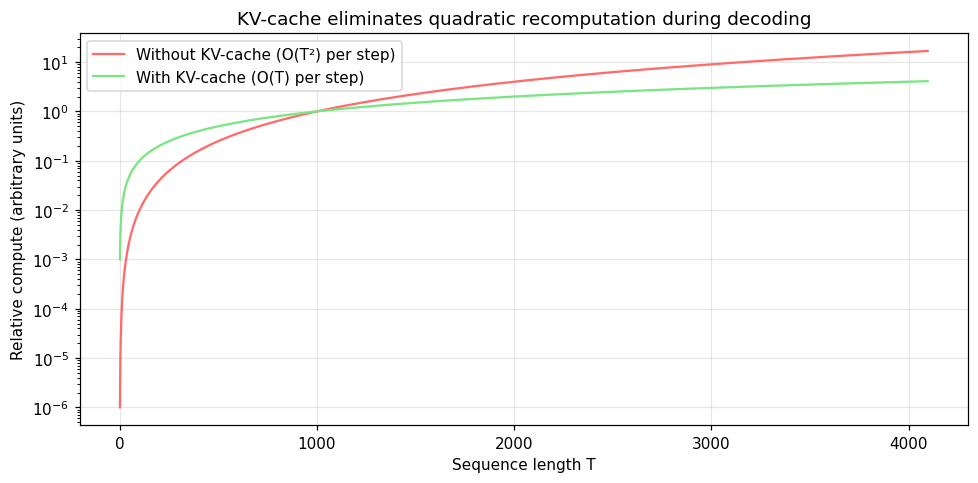

In [13]:
# Demo 9: Real autoregressive generation with SmolLM2
prompt_gen = "The key idea behind the transformer architecture is"
input_ids_gen = tokenizer.encode(prompt_gen, return_tensors="pt")

print(f"=== Autoregressive Generation (SmolLM2-135M base) ===\n")
print(f"Prompt: '{prompt_gen}'\n")

# Generate token-by-token to show the trace
gen_ids = input_ids_gen[0].tolist()
max_new = 40

print(f"{'Step':<6} {'New token':<15} {'Cumulative text'}")
print("-" * 70)
for step in range(max_new):
    with torch.no_grad():
        logits_g = model_base(torch.tensor([gen_ids])).logits[0, -1].float()
    probs_g = torch.softmax(logits_g / 0.8, dim=-1)
    next_id = torch.multinomial(probs_g, 1).item()
    gen_ids.append(next_id)
    new_tok = tokenizer.decode(next_id)
    full_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    if step < 10 or step % 5 == 0:
        print(f"{step:<6} {new_tok!r:<15} {full_text[:70]}")
    if next_id == tokenizer.eos_token_id:
        break

print(f"\n--- Final output ({len(gen_ids) - len(input_ids_gen[0])} new tokens) ---")
print(tokenizer.decode(gen_ids, skip_special_tokens=True))

# KV-cache cost comparison
seq_lengths = np.arange(1, 4097)
full_cost = seq_lengths**2
cached_cost = seq_lengths

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(seq_lengths, full_cost / 1e6, label="Without KV-cache (O(T²) per step)", color="#ff6b6b")
ax.plot(seq_lengths, cached_cost / 1e3, label="With KV-cache (O(T) per step)", color="#7ae582")
ax.set_xlabel("Sequence length T")
ax.set_ylabel("Relative compute (arbitrary units)")
ax.set_title("KV-cache eliminates quadratic recomputation during decoding")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()


### Demo 10: KV-Cache Memory Calculator

The KV-cache holds one K tensor and one V tensor per layer, per token, per batch element.
For BF16 storage (2 bytes per value), the total bytes are:

$$
\text{KV bytes} = 2 \times L \times h_{K} \times d_k \times T \times B \times 2.
$$


Model                   L   h_K   d_k  |  T=  512  T= 1024  T= 2048  T= 4096  T= 8192
------------------------------------------------------------------------------------------
SmolLM2-135M           30     3    64  |     11.8MB     23.6MB     47.2MB     94.4MB    188.7MB
Llama 3 8B             32     8   128  |     67.1MB    134.2MB    268.4MB    536.9MB     1.07GB
Llama 3 70B            80     8   128  |    167.8MB    335.5MB    671.1MB     1.34GB     2.68GB

Batch size = 1, dtype = BF16 (2 bytes)


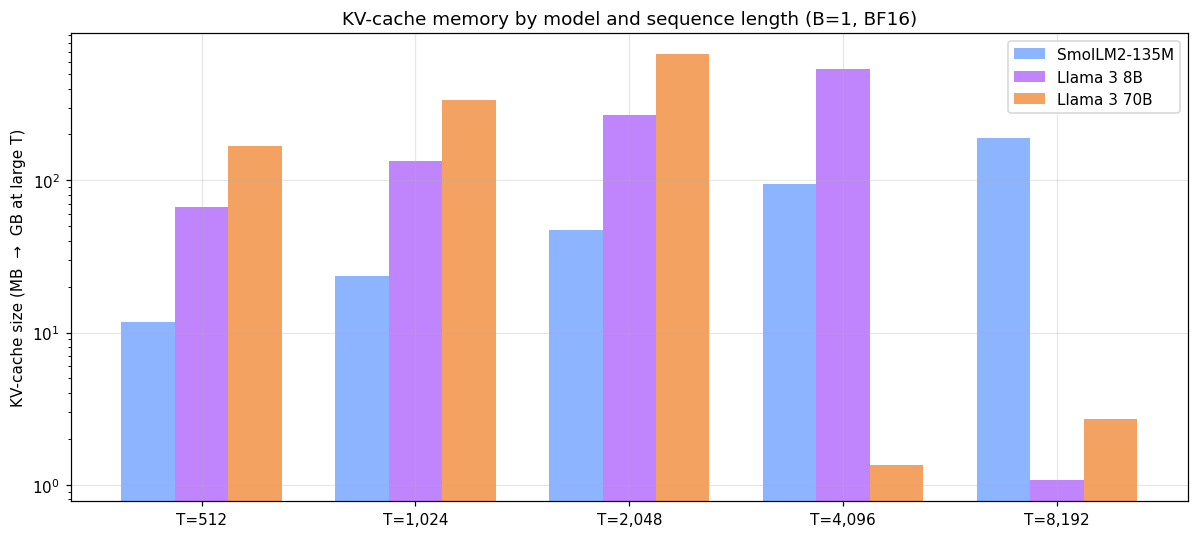


Llama 3 70B at T=8192, B=1: 2.68 GB of KV-cache
At B=8 (serving batch): 21.5 GB  — larger than the model weights for some GPU configurations.
This is why KV-cache quantisation (INT8/INT4) and eviction policies matter.


In [14]:
# Demo 10: KV-cache memory calculator (no model needed — pure arithmetic)
import math

# Model specs: (name, layers, h_KV, d_k)
model_specs = [
    ("SmolLM2-135M", 30, 3, 64),
    ("Llama 3 8B", 32, 8, 128),
    ("Llama 3 70B", 80, 8, 128),
]

seq_lengths_calc = [512, 1024, 2048, 4096, 8192]
batch_size_calc = 1
bytes_per_elem = 2  # BF16

print(f"{'Model':<20} {'L':>4} {'h_K':>5} {'d_k':>5}  |  ", end="")
print("  ".join(f"T={t:>5}" for t in seq_lengths_calc))
print("-" * (20 + 4 + 5 + 5 + 6 + 10 * len(seq_lengths_calc)))

table_data = {}
for name, L, h_kv_c, d_kc in model_specs:
    row_gb = []
    for T_c in seq_lengths_calc:
        kv_bytes_c = 2 * L * h_kv_c * d_kc * T_c * batch_size_calc * bytes_per_elem
        row_gb.append(kv_bytes_c / 1e9)
    table_data[name] = row_gb
    vals = "  ".join(f"{v * 1000:>7.1f}MB" if v < 1 else f"{v:>7.2f}GB" for v in row_gb)
    print(f"{name:<20} {L:>4} {h_kv_c:>5} {d_kc:>5}  |  {vals}")

print(f"\nBatch size = {batch_size_calc}, dtype = BF16 (2 bytes)")

# Bar chart
x_calc = np.arange(len(seq_lengths_calc))
width_calc = 0.25
colors_calc = ["#8db4ff", "#c084fc", "#f4a261"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, L, h_kv_c, d_kc) in enumerate(model_specs):
    gb_vals = table_data[name]
    ax.bar(x_calc + i * width_calc, [g * 1000 if g < 1 else g for g in gb_vals], width_calc, label=name, color=colors_calc[i])

ax.set_xticks(x_calc + width_calc)
ax.set_xticklabels([f"T={t:,}" for t in seq_lengths_calc])
ax.set_ylabel("KV-cache size (MB  →  GB at large T)")
ax.set_title(f"KV-cache memory by model and sequence length (B={batch_size_calc}, BF16)")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()

llama70b_8k_gb = table_data["Llama 3 70B"][-1]
print(f"\nLlama 3 70B at T=8192, B=1: {llama70b_8k_gb:.2f} GB of KV-cache")
print(f"At B=8 (serving batch): {llama70b_8k_gb * 8:.1f} GB  — larger than the model weights for some GPU configurations.")
print("This is why KV-cache quantisation (INT8/INT4) and eviction policies matter.")


## Scaling Laws and Compute-Optimal Training

**Why this exists.** Training a larger model on more data generally reduces loss, but compute is finite. *How* should we allocate a fixed compute budget between model size $N$ and dataset size $D$?

**How it works.** Hoffmann et al. (2022) — the Chinchilla study — showed that the loss follows approximately:

$$
L(N, D) \approx \frac{A}{N^\alpha} + \frac{B}{D^\beta} + L_\infty,
$$

where $\alpha \approx 0.34$, $\beta \approx 0.28$, and $L_\infty$ is the irreducible loss. The key insight: for a given compute budget $C \propto N \cdot D$, there is a *compute-optimal* allocation. GPT-3 was undertrained relative to its size; Chinchilla matched its performance with 4× fewer parameters but 4× more data.

### Four Dimensions of Scaling

It is important to distinguish *what* is being scaled. These are often conflated:

| Scaling type | What changes | Examples |
|-------------|-------------|---------|
| **Pretraining scaling** | Parameters, data, training compute | Chinchilla, Llama 3 |
| **Inference scaling** | Samples, search depth, verifier calls, tool loops | Self-consistency, best-of-N, ReAct |
| **Context scaling** | Usable context length and retrieval quality | YaRN, RAG, long-context fine-tuning |
| **Agent scaling** | Number of tools, steps, agents, traces | Multi-agent orchestration, hierarchical delegation |

Pretraining scaling improves the *base model*. Inference scaling improves *output quality per query* without retraining. Context scaling extends *what the model can read*. Agent scaling extends *what the system can do*. Each has different cost curves and diminishing-return profiles.

**Engineer lens.** Scaling laws inform infrastructure investment: is the next dollar better spent on a larger model or more training data? Post-Chinchilla, the trend is to train smaller models longer (Llama, Mistral, Phi).

**Failure mode.** Scaling laws are empirical fits, not physical laws. They break down at distribution boundaries and when post-training reshapes the loss landscape.


### Demo 11: Scaling-Law Frontier


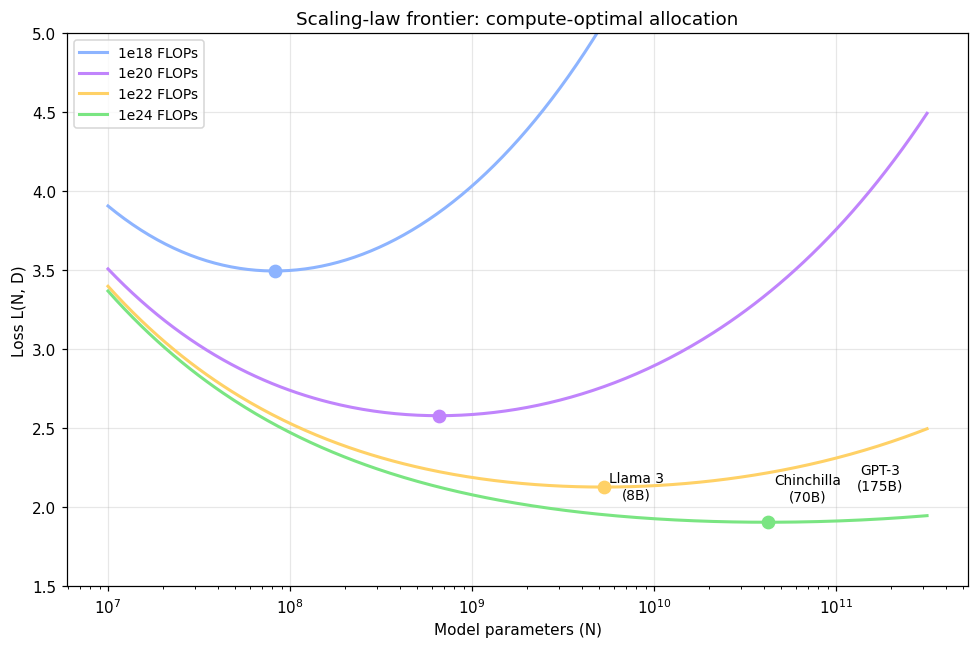

In [15]:
# Demo 11: Compute-optimal frontier (Chinchilla-style)
A, B, alpha, beta, L_inf = 400, 400, 0.34, 0.28, 1.69


def loss_fn(N, D):
    return A / N**alpha + B / D**beta + L_inf


# Iso-FLOP curves
fig, ax = plt.subplots(figsize=(9, 6))
N_range = np.logspace(7, 11.5, 300)

for flops, color, label in [
    (1e18, "#8db4ff", "1e18 FLOPs"),
    (1e20, "#c084fc", "1e20 FLOPs"),
    (1e22, "#ffd166", "1e22 FLOPs"),
    (1e24, "#7ae582", "1e24 FLOPs"),
]:
    D_range = flops / (6 * N_range)
    L_values = np.array([loss_fn(n, d) for n, d in zip(N_range, D_range)])
    valid = (D_range > 1e6) & (L_values < 10)
    ax.plot(N_range[valid], L_values[valid], label=label, color=color, linewidth=2)
    opt_idx = np.argmin(L_values[valid])
    ax.plot(N_range[valid][opt_idx], L_values[valid][opt_idx], "o", color=color, markersize=8, zorder=5)

models = {
    "GPT-3\n(175B)": (1.75e11, loss_fn(1.75e11, 3e11)),
    "Chinchilla\n(70B)": (7e10, loss_fn(7e10, 1.4e12)),
    "Llama 3\n(8B)": (8e9, loss_fn(8e9, 1.5e13)),
}
for name, (n, l) in models.items():
    ax.annotate(name, (n, l), fontsize=9, ha="center", xytext=(0, 12), textcoords="offset points")

ax.set_xscale("log")
ax.set_xlabel("Model parameters (N)")
ax.set_ylabel("Loss L(N, D)")
ax.set_title("Scaling-law frontier: compute-optimal allocation")
ax.legend(fontsize=9)
ax.set_ylim(1.5, 5)
plt.tight_layout()
plt.show()


## Post-Training: From Prediction to Instruction Following

Up to this point we have treated the model as a very competent continuation engine. Pretraining gives it broad statistical knowledge of language and text, but it does not by itself make the model a good assistant. A base model may continue the prompt in the style of a web page, imitate a forum thread, or complete a malformed instruction literally. **Post-training** is the stage where a text predictor is reshaped into something more useful for interactive work.

The first layer is usually **supervised fine-tuning** (SFT): curated pairs of prompts and desirable responses teach the model the surface conventions of helpful dialogue. This is the step that teaches turn-taking, answer formatting, refusals, and the expectation that a question should be answered rather than merely continued.

A second layer tries to shape behaviour more finely. Ouyang et al. (2022) framed this as **reinforcement learning from human feedback** (RLHF):

1. **SFT** on demonstration data.
2. **Reward model** training from human preference rankings.
3. **Policy optimization** via PPO:

$$
\max_\pi \; \mathbb{E}_{x \sim D,\, y \sim \pi(\cdot|x)} \big[ r_\theta(x, y) \big] - \beta \, \text{KL}\big[\pi \,\|\, \pi_{\text{SFT}}\big].
$$

In practice, many modern pipelines replace or supplement PPO with **Direct Preference Optimization** (DPO). Rafailov et al. (2023) showed that one can learn directly from preference pairs without explicitly training a separate reward model:

$$
\mathcal{L}_{\text{DPO}} = -\mathbb{E}\!\left[\log \sigma\!\left(\beta \log \frac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \beta \log \frac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)}\right)\right].
$$

Once the broad idea is clear, the engineering question becomes: *how much of the model should we actually update?* That is where adaptation strategies such as LoRA enter.

### Adaptation Strategies: From Full Fine-Tuning to LoRA

| Strategy | What changes | Trainable params | Typical use-case |
|----------|-------------|-----------------|------------------|
| **Full fine-tuning** | All weights | 100 % | Pre-training continuation |
| **Head-only** | LM head only | < 1 % | Task-specific classifiers |
| **Top-$k$ layer unfreezing** | Top $k$ layers + head | 5–30 % | Domain adaptation |
| **LoRA** (Hu et al., 2021) | Low-rank matrices $\Delta W = BA$ | 0.1–1 % | SFT/DPO with limited GPU |
| **QLoRA** (Dettmers et al., 2023) | LoRA on 4-bit quantised base | 0.1–1 % | Fine-tuning 70B on 24 GB GPU |

The central LoRA idea is economical. Instead of updating the full dense matrix $W \in \mathbb{R}^{d \times d}$, one learns a low-rank update:

$$
W' = W + \Delta W = W + B A, \qquad B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times d},\; r \ll d.
$$

Only $B$ and $A$ are trainable. At inference the product $BA$ is merged back into $W$, so the aligned model behaves like an ordinary dense model at runtime.

The practical picture is therefore layered rather than mystical: pretraining gives the model breadth, SFT gives it conversational form, preference optimisation shapes behaviour more subtly, and lightweight adaptation methods make those stages economically feasible. The failure modes are equally layered: reward hacking, narrow-data forgetting, brittle system-prompt compliance, and the familiar tension between helpfulness and overconfidence.


### Demo 12: Preference Optimization Intuition


=== Preference Optimization Intuition ===

Prompt:    Explain quantum computing in one sentence.
Preferred: Quantum computing uses qubits that can exist in superposition to explore many solutions simultaneously.
  reward = 3.571
Dispreferred: Quantum computing is basically really fast computers that use quantum stuff.
  reward = 2.000

Preference margin: 1.571


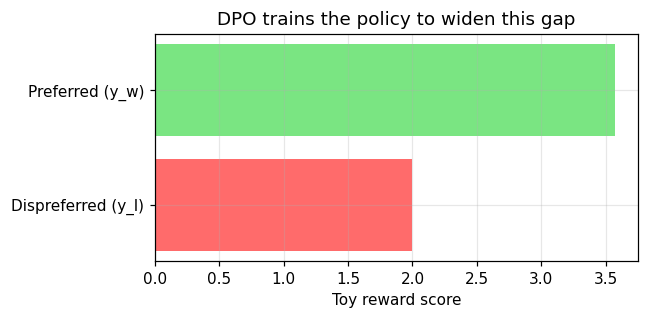


DPO loss pushes π(y_w|x) up and π(y_l|x) down relative to the reference policy.


In [16]:
# Demo 12: DPO-style preference comparison
print("=== Preference Optimization Intuition ===\n")

prompt = "Explain quantum computing in one sentence."
response_w = "Quantum computing uses qubits that can exist in superposition to explore many solutions simultaneously."
response_l = "Quantum computing is basically really fast computers that use quantum stuff."

keywords = {"qubits", "superposition", "quantum", "simultaneously", "solutions", "computing"}


def toy_reward(response):
    words = set(response.lower().split())
    overlap = len(words & keywords)
    return overlap / max(len(words), 1) * 10


r_w = toy_reward(response_w)
r_l = toy_reward(response_l)

print(f"Prompt:    {prompt}")
print(f"Preferred: {response_w}")
print(f"  reward = {r_w:.3f}")
print(f"Dispreferred: {response_l}")
print(f"  reward = {r_l:.3f}")
print(f"\nPreference margin: {r_w - r_l:.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["Dispreferred (y_l)", "Preferred (y_w)"], [r_l, r_w], color=["#ff6b6b", "#7ae582"])
ax.set_xlabel("Toy reward score")
ax.set_title("DPO trains the policy to widen this gap")
plt.tight_layout()
plt.show()

print("\nDPO loss pushes π(y_w|x) up and π(y_l|x) down relative to the reference policy.")


### Demo 13: Base vs Instruct — Same Prompt, Different Behavior

The clearest evidence that post-training *works* is comparing a base model with its
instruct-aligned variant on the same prompt.


In [17]:
# Demo 13: Base vs Instruct comparison on the same prompt
comparison_prompt = "Explain what a neural network is in one sentence."


def generate_text(model, prompt_text, max_new_tokens=60, temperature=0.7):
    ids = tokenizer.encode(prompt_text, return_tensors="pt")
    gen_ids = ids[0].tolist()
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(torch.tensor([gen_ids])).logits[0, -1].float()
        probs = torch.softmax(logits / temperature, dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        gen_ids.append(next_id)
        if next_id == tokenizer.eos_token_id:
            break
    return tokenizer.decode(gen_ids, skip_special_tokens=True)


print("=== Base vs Instruct Comparison ===\n")
print(f"Prompt: '{comparison_prompt}'\n")

base_output = generate_text(model_base, comparison_prompt)
print(f"--- Base model (SmolLM2-135M) ---")
print(f"{base_output}\n")

inst_output = generate_text(model_inst, comparison_prompt)
print(f"--- Instruct model (SmolLM2-135M-Instruct) ---")
print(f"{inst_output}\n")

print("Observation: the base model continues the text as a document.")
print("The instruct model attempts to answer the question directly.")
print("This behavioral shift is the result of SFT + DPO alignment.")


=== Base vs Instruct Comparison ===

Prompt: 'Explain what a neural network is in one sentence.'

--- Base model (SmolLM2-135M) ---
Explain what a neural network is in one sentence.

How can we use neural networks to solve a real-world problem?

We will be using neural networks to solve this problem. Let’s take a look at an example and see how this works.

Example: Finding the most useful item in the shopping cart

Suppose

--- Instruct model (SmolLM2-135M-Instruct) ---
Explain what a neural network is in one sentence. It is a machine learning model that is designed to learn from data and make predictions or decisions based on that data, while also incorporating some form of human interpretation and context.

In terms of the role of machines, a neural network is often used in applications that involve data analysis, machine learning,

Observation: the base model continues the text as a document.
The instruct model attempts to answer the question directly.
This behavioral shift is the r

### Demo 14: Chat Templates

In practice, instruct models expect a structured message format — not raw text.
`apply_chat_template` converts a list of `{role, content}` messages into the model's
expected token sequence, including special tokens and delimiters.


In [18]:
# Demo 14: Chat template — what the model actually sees
messages = [
    {"role": "user", "content": "What is attention in a transformer?"},
]

tokenizer_inst = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
formatted = tokenizer_inst.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

print("=== Chat Template ===\n")
print("Input messages:")
for m in messages:
    print(f"  [{m['role']}] {m['content']}")

print(f"\nFormatted prompt (what the model sees):\n")
print(repr(formatted))
print(f"\n--- Readable view ---\n{formatted}")

ids = tokenizer_inst.encode(formatted, return_tensors="pt")
print(f"\nToken count: {ids.shape[1]} tokens for a single-turn message")
print("Note: the template adds special tokens and structure overhead.")

with torch.no_grad():
    gen_out = model_inst.generate(ids, max_new_tokens=80, temperature=0.7, do_sample=True)
response = tokenizer_inst.decode(gen_out[0][ids.shape[1] :], skip_special_tokens=True)
print(f"\nInstruct model response:\n{response}")


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


=== Chat Template ===

Input messages:
  [user] What is attention in a transformer?

Formatted prompt (what the model sees):

'<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nWhat is attention in a transformer?<|im_end|>\n<|im_start|>assistant\n'

--- Readable view ---
<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
What is attention in a transformer?<|im_end|>
<|im_start|>assistant


Token count: 37 tokens for a single-turn message
Note: the template adds special tokens and structure overhead.

Instruct model response:
Attentional processing in a transformer refers to the process of intentionally focusing attention on specific elements within a complex system, such as a network, a database, or even a single entity, in order to optimize its performance, efficiency, or effectiveness.

In a transformer, attention is used to perform tasks, such as filter

## Optional: Mixture of Experts (MoE)

> This section is supplementary. MoE is an important architecture variant but is not required to understand the inference pipeline or reasoning-time compute in Part II.

**Why this exists.** Dense transformers activate *every* parameter for *every* token. MoE architectures decouple total parameter count from per-token compute by routing each token to only a subset of expert sub-networks.

**How it works.** The feed-forward layer is replaced with $E$ parallel experts and a gating router:

$$
G(x) = \text{TopK}\!\big(\text{softmax}(W_g \, x)\big), \qquad
y = \sum_{i \in \text{TopK}} g_i(x) \cdot E_i(x).
$$

| Model | Total params | Active params | Experts | Top-K |
|-------|-------------|--------------|---------|-------|
| Switch Transformer | 1.6T | ~100B | 128 | 1 |
| Mixtral 8×7B | 47B | 13B | 8 | 2 |
| DeepSeek-V3 | 671B | 37B | 256 | 8 |

> **Common confusion.** MoEs are a *model architecture* (single forward pass). They are **not** multi-agent systems, even though "expert" appears in both contexts.

**Failure mode.** Router instability, load imbalance causing expert collapse, debugging difficulty.


### Demo 15: MoE Routing and Load Balance


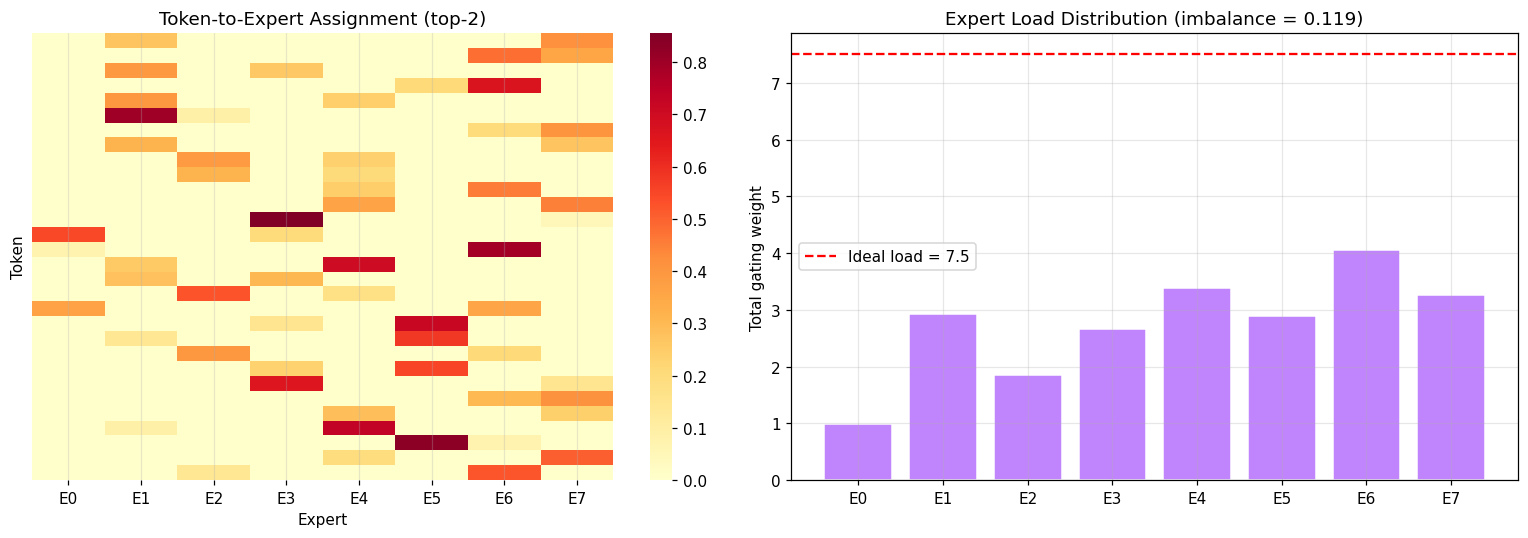

In [19]:
# Demo 15: MoE routing simulation
n_tokens, n_experts, top_k = 30, 8, 2
d_tok = 32

token_vecs = rng.standard_normal((n_tokens, d_tok))
W_gate = rng.standard_normal((d_tok, n_experts)) * 0.3

gate_logits = token_vecs @ W_gate
gate_probs = softmax(gate_logits)

topk_indices = np.argsort(-gate_probs, axis=1)[:, :top_k]
assignment = np.zeros((n_tokens, n_experts))
for t in range(n_tokens):
    for k in range(top_k):
        assignment[t, topk_indices[t, k]] = gate_probs[t, topk_indices[t, k]]

load = assignment.sum(axis=0)
ideal_load = n_tokens * top_k / n_experts
imbalance = load.std() / ideal_load

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(assignment, cmap="YlOrRd", ax=axes[0], xticklabels=[f"E{i}" for i in range(n_experts)], yticklabels=False)
axes[0].set_xlabel("Expert")
axes[0].set_ylabel("Token")
axes[0].set_title("Token-to-Expert Assignment (top-2)")

axes[1].bar([f"E{i}" for i in range(n_experts)], load, color="#c084fc", edgecolor="white")
axes[1].axhline(ideal_load, color="red", linestyle="--", label=f"Ideal load = {ideal_load:.1f}")
axes[1].set_ylabel("Total gating weight")
axes[1].set_title(f"Expert Load Distribution (imbalance = {imbalance:.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()


# What's Next

This notebook has covered the full forward-pass pipeline: tokenization, embeddings, positional encoding, attention, transformer blocks, generation strategies, post-training alignment, and mixture-of-experts. You now have a working mental model of what happens inside an LLM from the moment text enters to the moment the next token is sampled.

But one question is still hanging in the air: *how does a prompt actually steer a reply?* Why does adding "Let's think step by step" sometimes change the answer? Why can three examples in the context teach the model a new task without altering a single parameter?

The next notebook in this series — [Prompt Engineering](prompt_engineering_how_they_work.ipynb) — picks up exactly here, developing the mechanics of prompt conditioning, in-context learning, chain-of-thought reasoning, self-consistency, and the bridge from prompting into agentic loops.


# Diagnostics, Limitations, and Open Problems

## LLM Failure Modes

| Failure | Root Cause | Mitigation |
|---------|-----------|------------|
| **Hallucination** | Next-token prediction rewards plausibility, not truth | RAG, grounding, citations, verification |
| **Repetition loops** | Low temperature + high top-p can trap decoding | Repetition penalties, frequency penalties |
| **Lost in the middle** | Attention bias toward start/end of context | Place critical info at start/end, chunk sizing |
| **Tokenizer artefacts** | Subword units don't align with human units | Character-level postprocessing for counting tasks |
| **Systematic reasoning errors** | Fixed-depth computation insufficient for hard problems | CoT, self-consistency, trajectory search |
| **Reward hacking** | RLHF/DPO models exploit reward model weaknesses | Diverse reward signals, constitutional AI |

## Open Problems (as of April 2026)

1. **Grounding**: connecting model outputs to verifiable facts remains unsolved at scale.
2. **Faithfulness of CoT**: models can produce reasoning chains that don't reflect their actual computation.
3. **Scaling law generalization**: will current scaling trends continue, or are we approaching diminishing returns?
4. **Efficient long-context**: sub-quadratic attention that preserves quality is still an active research area.
5. **Evaluation**: measuring open-ended generation quality without human raters is an open problem.


# Reproducibility

This notebook requires **PyTorch** and **Hugging Face Transformers** in addition to the standard numerical stack. The first run downloads SmolLM2-135M model weights (~540 MB total for both variants). No API keys or GPU are required — all inference runs on CPU.

**To regenerate this notebook:**

```bash
python scripts/generate_llms_how_they_work.py
```

**To export:**

```bash
python scripts/export_notebook.py --notebook llms_how_they_work.ipynb --output-dir exports
```

**Companion notebooks:** [Prompt Engineering](prompt_engineering_how_they_work.ipynb) covers prompt conditioning, in-context learning, chain-of-thought, and reasoning-time compute. [How Agents Work](agents_how_they_work.ipynb) covers agent architectures, tool use, orchestration, memory, security, evaluation, and a capstone implementation.


In [20]:
# Environment report
import platform

print(f"Platform:      {platform.platform()}")
print(f"Python:        {sys.version}")
print(f"NumPy:         {np.__version__}")
print(f"Pandas:        {pd.__version__}")
print(f"Matplotlib:    {plt.matplotlib.__version__}")
print(f"Seaborn:       {sns.__version__}")
print(f"PyTorch:       {torch.__version__}")
print(f"Transformers:  {_tf.__version__}")


Platform:      Windows-11-10.0.26200-SP0
Python:        3.12.12 | packaged by conda-forge | (main, Jan 26 2026, 23:38:32) [MSC v.1944 64 bit (AMD64)]
NumPy:         2.2.6
Pandas:        2.2.3
Matplotlib:    3.8.4
Seaborn:       0.13.2
PyTorch:       2.11.0+cpu
Transformers:  5.6.2


# References

1. Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need*. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
2. Brown, T., Mann, B., Ryder, N., et al. (2020). *Language Models are Few-Shot Learners*. [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)
3. Hoffmann, J., Borgeaud, S., Mensch, A., et al. (2022). *Training Compute-Optimal Large Language Models* (Chinchilla). [arXiv:2203.15556](https://arxiv.org/abs/2203.15556)
4. Ouyang, L., Wu, J., Jiang, X., et al. (2022). *Training language models to follow instructions with human feedback* (InstructGPT/RLHF). [arXiv:2203.02155](https://arxiv.org/abs/2203.02155)
5. Rafailov, R., Sharma, A., Mitchell, E., et al. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model* (DPO). [arXiv:2305.18290](https://arxiv.org/abs/2305.18290)
6. Zhao, W.X., Zhou, K., Li, J., et al. (2023). *A Survey of Large Language Models*. [arXiv:2303.18223](https://arxiv.org/abs/2303.18223)
7. Fedus, W., Zoph, B., Shazeer, N. (2021). *Switch Transformers: Scaling to Trillion Parameter Models with Simple and Efficient Sparsity*. [arXiv:2101.03961](https://arxiv.org/abs/2101.03961)
8. Jiang, A.Q., Sablayrolles, A., Roux, A., et al. (2024). *Mixtral of Experts*. [arXiv:2401.04088](https://arxiv.org/abs/2401.04088)
9. DeepSeek-AI (2024). *DeepSeek-V3 Technical Report*. [arXiv:2412.19437](https://arxiv.org/abs/2412.19437)
10. Liu, N.F., Lin, K., Hewitt, J., et al. (2023). *Lost in the Middle: How Language Models Use Long Contexts*. [arXiv:2307.03172](https://arxiv.org/abs/2307.03172)
11. Holtzman, A., Buys, J., Du, L., Forbes, M., Choi, Y. (2020). *The Curious Case of Neural Text Degeneration*. [arXiv:1904.09751](https://arxiv.org/abs/1904.09751)
12. Allal, L.B., Lozhkov, A., Penedo, G., et al. (2025). *SmolLM2 — When Smol Goes Big*. [arXiv:2502.02737](https://arxiv.org/abs/2502.02737)
13. Dettmers, T., Pagnoni, A., Holtzman, A., Zettlemoyer, L. (2023). *QLoRA: Efficient Finetuning of Quantized Language Models*. [arXiv:2305.14314](https://arxiv.org/abs/2305.14314)
14. Hu, E.J., Shen, Y., Wallis, P., et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
15. Su, J., Lu, Y., Pan, S., Murtadha, A., Wen, B., Liu, Y. (2021). *RoFormer: Enhanced Transformer with Rotary Position Embedding* (RoPE). [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)
16. Ainslie, J., Lee-Thorp, J., de Jong, M., et al. (2023). *GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints*. [arXiv:2305.13245](https://arxiv.org/abs/2305.13245)
17. Dao, T., Fu, D.Y., Ermon, S., Rudra, A., Ré, C. (2022). *FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness*. [arXiv:2205.14135](https://arxiv.org/abs/2205.14135)
18. Zhang, B. & Sennrich, R. (2019). *Root Mean Square Layer Normalization*. [arXiv:1910.07467](https://arxiv.org/abs/1910.07467)
19. Shazeer, N. (2020). *GLU Variants Improve Transformer*. [arXiv:2002.05202](https://arxiv.org/abs/2002.05202)
20. Devlin, J., Chang, M.-W., Lee, K., Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
21. Raffel, C., Shazeer, N., Roberts, A., et al. (2020). *Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer* (T5). [arXiv:1910.10683](https://arxiv.org/abs/1910.10683)
22. Lewis, M., Liu, Y., Goyal, N., et al. (2020). *BART: Denoising Sequence-to-Sequence Pre-training*. [arXiv:1910.13461](https://arxiv.org/abs/1910.13461)
23. Radford, A., Narasimhan, K., Salimans, T., Sutskever, I. (2018). *Improving Language Understanding by Generative Pre-Training* (GPT-1). [OpenAI](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)


GitHub repository: [https://github.com/adamd1985/quant_research/blob/main/llms_how_they_work.ipynb](https://github.com/adamd1985/quant_research/blob/main/llms_how_they_work.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/how-llms-work)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.
